# 03. Modelos de Machine Learning

# Importando as Bibliotecas

In [1]:
# ================================
# Utilitários
# ================================
import time
import joblib

# ================================
# Manipulação de dados
# ================================
import pandas as pd
import numpy as np

# ================================
# Visualização de dados
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Divisão, validação e otimização
# ================================
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_validate,
    StratifiedKFold,
    cross_val_score,
    learning_curve
)

# ================================
# Pré-processamento
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

# ================================
# Modelos de Machine Learning
# ================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from lightgbm import LGBMClassifier
import xgboost as xgb

# ================================
# Avaliação de modelos
# ================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    make_scorer
)

# ================================
# Interpretabilidade
# ================================
import shap

import optuna
import optuna.visualization as viz

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# 2. Leitura da Base de Dados

In [2]:
dados = pd.read_csv("../data/dados_modelo.csv", index_col=0)
dados.head()

,inadimplente_2_anos,utilizacao_credito,idade,atrasos_30_59_dias,razao_divida,renda_mensal,linhas_credito_abertas,atrasos_90_dias,emprestimos_imobiliarios,atrasos_60_89_dias,numero_dependentes,total_atrasos,atraso_grave
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,2,0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,2,1
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,1,0


# 3. Validação rápida dos Dados

In [3]:
print(f"Total Linhas -> {dados.shape[0]}")
print(f"Total Colunas -> {dados.shape[1]}")
print(f"\n===== Informações dos dados =====\n")
print(dados.info())

Total Linhas -> 149999
Total Colunas -> 13

===== Informações dos dados =====

<class 'pandas.DataFrame'>
Index: 149999 entries, 1 to 150000
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   inadimplente_2_anos       149999 non-null  int64  
 1   utilizacao_credito        149999 non-null  float64
 2   idade                     149999 non-null  int64  
 3   atrasos_30_59_dias        149999 non-null  int64  
 4   razao_divida              149999 non-null  float64
 5   renda_mensal              120268 non-null  float64
 6   linhas_credito_abertas    149999 non-null  int64  
 7   atrasos_90_dias           149999 non-null  int64  
 8   emprestimos_imobiliarios  149999 non-null  int64  
 9   atrasos_60_89_dias        149999 non-null  int64  
 10  numero_dependentes        146075 non-null  float64
 11  total_atrasos             149999 non-null  int64  
 12  atraso_grave              149999 non-

# 4. Definição da Variável Alvo + Separação de Treino

In [4]:
X = dados.drop("inadimplente_2_anos", axis=1)

y = dados["inadimplente_2_anos"]

In [5]:
X_temp, X_teste, y_temp, y_teste = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_treino, X_val, y_treino, y_val = train_test_split(X_temp, y_temp, stratify=y_temp, test_size=0.20, random_state=42)

In [6]:
print(f"Treino -> {len(X_treino)}")
print(f"Validação -> {len(X_val)}")
print(f"Teste -> {len(X_teste)}")

Treino -> 95999
Validação -> 24000
Teste -> 30000


# 5. Pré-Processamento dos Dados

In [7]:
var_numericas = dados.select_dtypes(include="number").columns.difference(["inadimplente_2_anos"]).tolist()

In [8]:
pipeline_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [9]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, var_numericas)
    ]
)

X_treino_tratado = preprocessador.fit_transform(X_treino)
X_val_tratado = preprocessador.transform(X_val)
X_teste_tratado = preprocessador.transform(X_teste)

In [10]:
num_cols = list(var_numericas)

X_treino = pd.DataFrame(X_treino_tratado, columns= num_cols)
X_val = pd.DataFrame(X_val_tratado, columns=num_cols)
X_teste = pd.DataFrame(X_teste_tratado, columns=num_cols)

In [11]:
X_treino.head()

,atraso_grave,atrasos_30_59_dias,atrasos_60_89_dias,atrasos_90_dias,emprestimos_imobiliarios,idade,linhas_credito_abertas,numero_dependentes,razao_divida,renda_mensal,total_atrasos,utilizacao_credito
0,-0.242914,-0.100251,-0.05813,-0.064006,-0.015893,0.182305,1.263835,2.048514,-0.177313,0.437743,-0.07449,-0.027710
1,-0.242914,-0.100251,-0.05813,-0.064006,0.871170,-0.495829,-0.091894,0.239108,-0.177252,0.156936,-0.07449,-0.026546
2,-0.242914,-0.100251,-0.05813,-0.064006,0.871170,-1.377402,-0.672921,-0.665595,-0.176882,-0.340164,-0.07449,-0.026807
3,-0.242914,-0.100251,-0.05813,-0.064006,-0.015893,1.199505,-0.479245,-0.665595,0.462815,-0.086860,-0.07449,-0.027280
4,-0.242914,-0.100251,-0.05813,-0.064006,-0.015893,-0.292389,0.295457,-0.665595,-0.177225,-0.143905,-0.07449,-0.027266


# 6. Aplicação do VarianceThreshold

In [12]:
selector_variance = VarianceThreshold(threshold=0.05)

X_treino_variance = selector_variance.fit_transform(X_treino)
X_val_variance = selector_variance.transform(X_val)
X_teste_variance = selector_variance.transform(X_teste)

features_variance = X_treino.columns[selector_variance.get_support()]

print(f"Features Originais -> {X_treino.shape[1]}")
print(f"Features Selecionadas -> {len(features_variance)}")

print(f"\nFeatures mantidas:")
print(features_variance.tolist())

Features Originais -> 12
Features Selecionadas -> 12

Features mantidas:
['atraso_grave', 'atrasos_30_59_dias', 'atrasos_60_89_dias', 'atrasos_90_dias', 'emprestimos_imobiliarios', 'idade', 'linhas_credito_abertas', 'numero_dependentes', 'razao_divida', 'renda_mensal', 'total_atrasos', 'utilizacao_credito']


# 7. Treinamento e comparação inicial dos Modelos

In [13]:
negativos = (y == 0).sum()
positivos = (y == 1).sum()

scale_pos_weight = negativos / positivos

scale_pos_weight

np.float64(13.96100139636944)

In [14]:
modelos_classificacao = {
    "Regressao Logistica": LogisticRegression(max_iter=3000, random_state=42, class_weight="balanced"),
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(max_depth=5, n_estimators=300, random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": xgb.XGBClassifier(max_depth=5, n_estimators=300, random_state=42, scale_pos_weight=scale_pos_weight),
    "LightGBM": LGBMClassifier(n_estimators=300, max_depth=5, random_state=42, class_weight="balanced", verbose=-1)
}

In [15]:
def calcula_metricas(y_val, y_pred):
    acuracia = accuracy_score(y_val, y_pred)
    precision_0 = precision_score(y_val, y_pred, pos_label=0)
    precision_1 = precision_score(y_val, y_pred, pos_label=1)
    recall_0 = recall_score(y_val, y_pred, pos_label=0)
    recall_1 = recall_score(y_val, y_pred, pos_label=1)
    f1_macro = f1_score(y_val, y_pred, average="macro")

    return {
        "Accuracy": acuracia,
        "Precision_0": precision_0,
        "Precision_1": precision_1,
        "Recall_0": recall_0,
        "Recall_1": recall_1,
        "F1_Macro": f1_macro
    }

In [16]:
resultados = []

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Modelo"] = nome

    resultados.append(metricas)

resultados = pd.DataFrame(resultados)
resultados = resultados.sort_values(by="F1_Macro", ascending=False).round(3)
resultados

,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1_Macro,Modelo
4,0.838,0.972,0.241,0.851,0.661,0.630,XGBoost
2,0.825,0.977,0.238,0.832,0.729,0.629,Random Forest
5,0.814,0.978,0.227,0.818,0.746,0.620,LightGBM
0,0.834,0.968,0.226,0.850,0.610,0.618,Regressao Logistica
3,0.934,0.944,0.525,0.989,0.176,0.615,KNN
1,0.753,0.982,0.187,0.749,0.805,0.577,Árvore de Decisão


In [17]:
for nome in["XGBoost", "Random Forest", "LightGBM"]:
    modelo = modelos_classificacao[nome]
    modelo.fit(X_treino, y_treino)
    previsao = modelo.predict(X_val)

    print(f"Modelo: {nome}")
    print(classification_report(y_val, previsao))
    print('-'*60)

Modelo: XGBoost
              precision    recall  f1-score   support

           0       0.97      0.85      0.91     22396
           1       0.24      0.66      0.35      1604

    accuracy                           0.84     24000
   macro avg       0.61      0.76      0.63     24000
weighted avg       0.92      0.84      0.87     24000

------------------------------------------------------------
Modelo: Random Forest
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     22396
           1       0.24      0.73      0.36      1604

    accuracy                           0.83     24000
   macro avg       0.61      0.78      0.63     24000
weighted avg       0.93      0.83      0.86     24000

------------------------------------------------------------
Modelo: LightGBM
              precision    recall  f1-score   support

           0       0.98      0.82      0.89     22396
           1       0.23      0.75      0.35      1604

    a

# 8. Otimização de Hiperparametros

In [18]:
xgb_model = xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced")
gbm_model = LGBMClassifier(random_state=42, class_weight="balanced", verbose=-1)

In [19]:
scorer_recall_1 = make_scorer(recall_score, pos_label=1)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [20]:
# XGBoost - Otimização
param_xgb = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.5, 1],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 2, 5]
}

busca_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_xgb,
    n_iter=15,
    scoring=scorer_recall_1,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

busca_xgb.fit(X_treino, y_treino)

print(f"Melhor Score -> {busca_xgb.best_score_}")
print(f"\nMelhores Params -> {busca_xgb.best_params_}")

Melhor Score -> 0.7743493844475612

Melhores Params -> {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 1.0}


In [21]:
param_rf = {
    "n_estimators": [200, 400, 600],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"],
}

busca_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_rf,
    n_iter=15,
    scoring=scorer_recall_1,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

busca_rf.fit(X_treino, y_treino)

print(f"Melhor Score -> {busca_rf.best_score_}")
print(f"Melhores Hiperparametros -> {busca_rf.best_params_}")

Melhor Score -> 0.7338320087268193
Melhores Hiperparametros -> {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10}


In [22]:
param_lgbm = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 45],
    "max_depth": [5, 10, -1],
    "min_child_samples": [20, 50, 100],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

busca_gbm = RandomizedSearchCV(
    estimator=gbm_model,
    param_distributions=param_lgbm,
    n_iter=15,
    scoring=scorer_recall_1,
    cv=cv,
    random_state=42
)

busca_gbm.fit(X_treino, y_treino)

print(f"Melhor Score -> {busca_gbm.best_score_}")
print(f"Melhores Hiperparametros -> {busca_gbm.best_params_}")

Melhor Score -> 0.7632850241545893
Melhores Hiperparametros -> {'subsample': 1.0, 'num_leaves': 15, 'n_estimators': 600, 'min_child_samples': 100, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


# 9. Resultados após a otimização

In [23]:
modelos_tunados = {
    "XGBoost Tunado": busca_xgb.best_estimator_,
    "Random Forest Tunado": busca_rf.best_estimator_,
    "LightGBM Tunado": busca_gbm.best_estimator_
}

resultados_tuning = []

for nome, modelo in modelos_tunados.items():
    modelo.fit(X_treino, y_treino)
    previsao = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, previsao)

    metricas["Modelo"] = nome

    resultados_tuning.append(metricas)

resultados_tuning = pd.DataFrame(resultados_tuning)
resultados_tuning = resultados_tuning.sort_values(by="Recall_1", ascending=False)
resultados_tuning

,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1_Macro,Modelo
0,0.793833,0.981298,0.215356,0.794204,0.788653,0.608110,XGBoost Tunado
2,0.799083,0.980374,0.218115,0.800723,0.776185,0.611012,LightGBM Tunado
1,0.814333,0.979474,0.230537,0.818182,0.760599,0.622710,Random Forest Tunado


In [24]:
for nome in["XGBoost Tunado", "Random Forest Tunado", "LightGBM Tunado"]:
    modelo = modelos_tunados[nome]
    modelo.fit(X_treino, y_treino)
    previsao = modelo.predict(X_val)

    print(f"Modelo -> {nome}")
    print(classification_report(y_val, previsao))
    print('-'*60)

Modelo -> XGBoost Tunado
              precision    recall  f1-score   support

           0       0.98      0.79      0.88     22396
           1       0.22      0.79      0.34      1604

    accuracy                           0.79     24000
   macro avg       0.60      0.79      0.61     24000
weighted avg       0.93      0.79      0.84     24000

------------------------------------------------------------
Modelo -> Random Forest Tunado
              precision    recall  f1-score   support

           0       0.98      0.82      0.89     22396
           1       0.23      0.76      0.35      1604

    accuracy                           0.81     24000
   macro avg       0.61      0.79      0.62     24000
weighted avg       0.93      0.81      0.86     24000

------------------------------------------------------------
Modelo -> LightGBM Tunado
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     22396
           1       0.22      0.78

## Matriz de Confusão - Modelos Otimizados

In [25]:
modelo_xgb_tunado = busca_xgb.best_estimator_
modelo_rf_tunado = busca_rf.best_estimator_
modelo_gbm_tunado = busca_gbm.best_estimator_

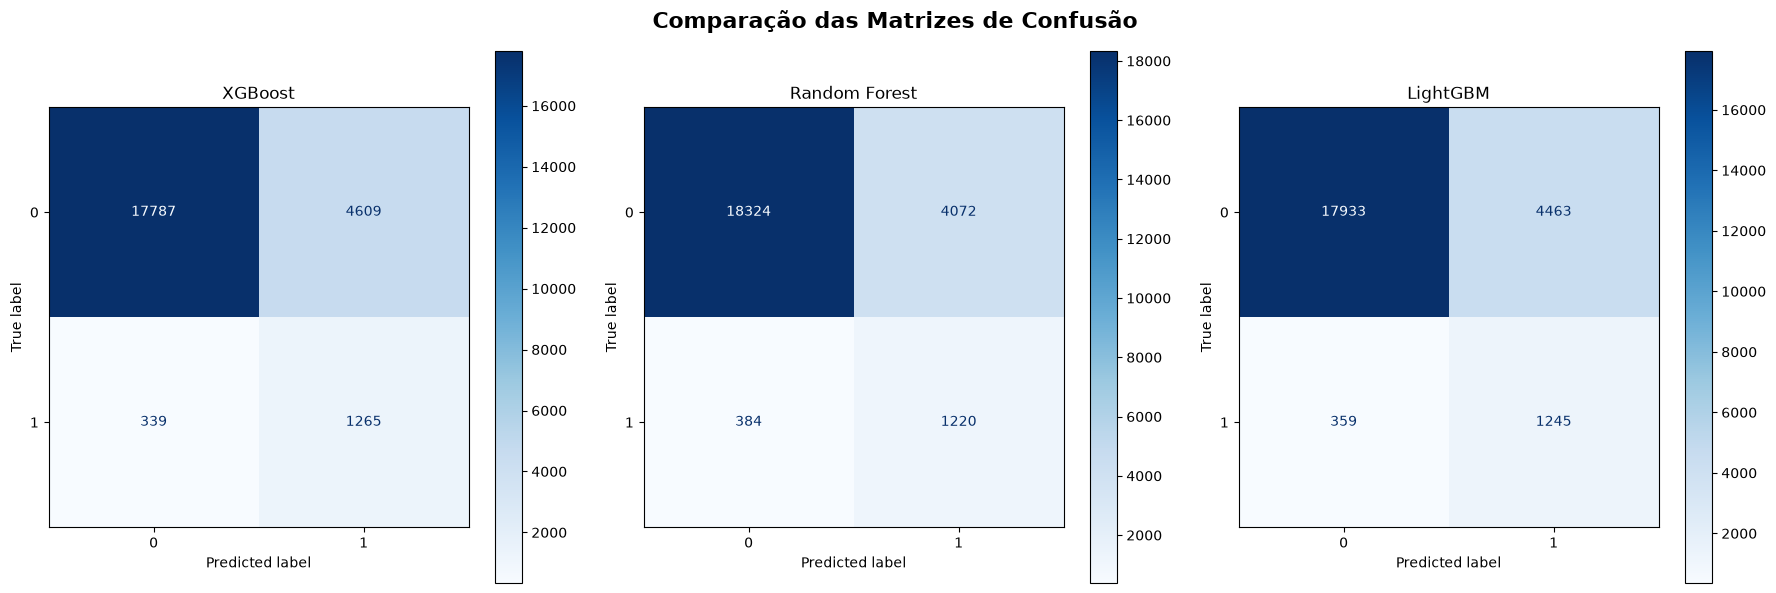

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

ConfusionMatrixDisplay.from_estimator(modelo_xgb_tunado, X_val, y_val, cmap="Blues", ax=axes[0])
axes[0].set_title("XGBoost")

ConfusionMatrixDisplay.from_estimator(modelo_rf_tunado, X_val, y_val, cmap="Blues", ax=axes[1])
axes[1].set_title("Random Forest")

ConfusionMatrixDisplay.from_estimator(modelo_gbm_tunado, X_val, y_val, cmap="Blues", ax=axes[2])
axes[2].set_title("LightGBM")

plt.suptitle("Comparação das Matrizes de Confusão", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Análise Curva ROC - Modelos Otimizados

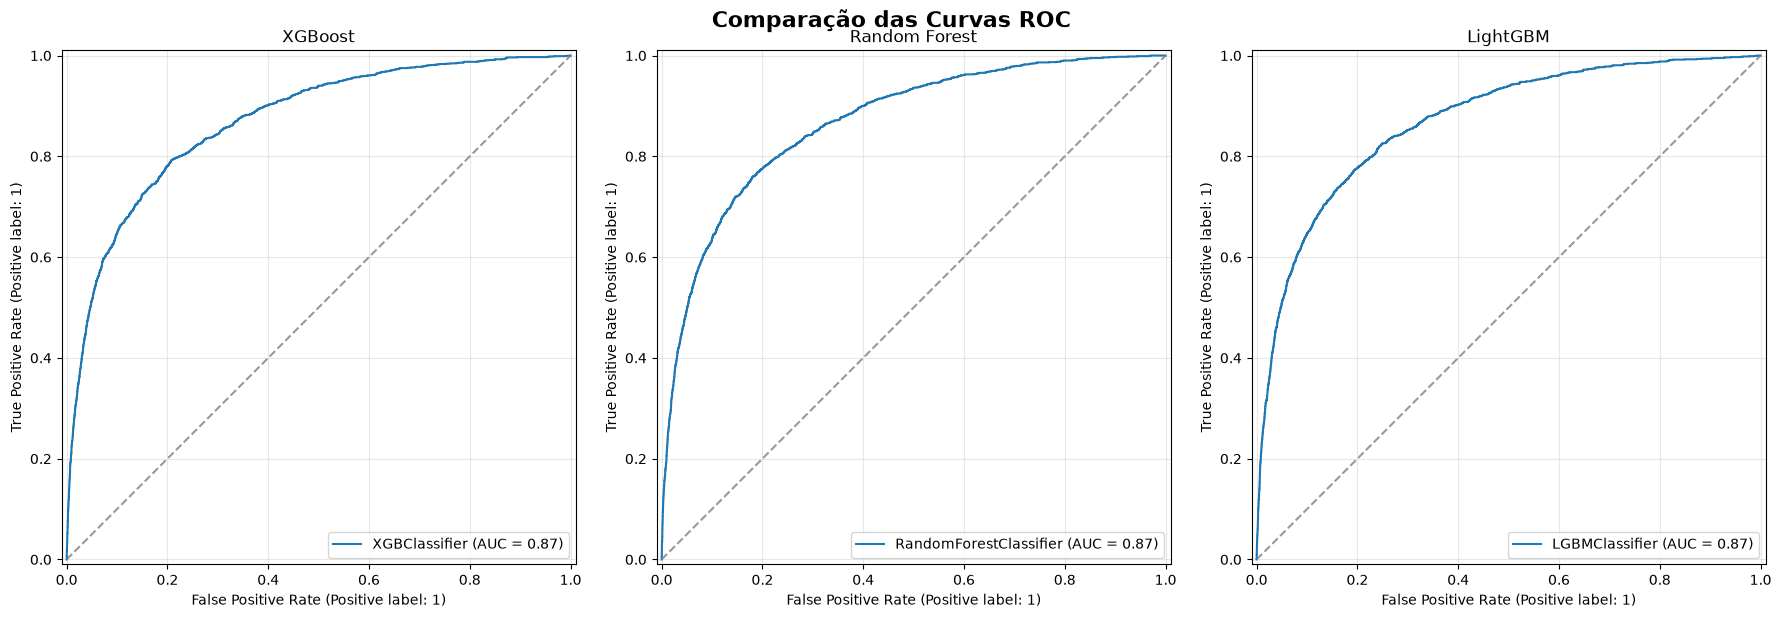

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

RocCurveDisplay.from_estimator(modelo_xgb_tunado, X_val, y_val, ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
axes[0].set_title("XGBoost")
axes[0].grid(alpha=0.3)

RocCurveDisplay.from_estimator(modelo_rf_tunado, X_val, y_val, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
axes[1].set_title("Random Forest")
axes[1].grid(alpha=0.3)

RocCurveDisplay.from_estimator(modelo_gbm_tunado, X_val, y_val, ax=axes[2])
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
axes[2].set_title("LightGBM")
axes[2].grid(alpha=0.3)

plt.suptitle("Comparação das Curvas ROC", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# 10. Optuna dos Modelos XGBoost e LightGBM

## Modelo XGBoost Optuna - 20 iterações

In [28]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 250, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 5),
        "subsample": trial.suggest_float("subsample", 0.8, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.8, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 5)
    }

    modelo = xgb.XGBClassifier(**params, scale_pos_weight=scale_pos_weight, random_state=42)

    score = cross_val_score(modelo, X_treino, y_treino, cv=cv, scoring=scorer_recall_1, n_jobs=-1)

    return score.mean()

In [29]:
sampler = optuna.samplers.TPESampler(seed=42)

study_xgb = optuna.create_study(
    direction="maximize"
)

study_xgb.optimize(
    objective_xgb,
    n_trials=50
)

[I 2026-09-24 08:01:42,363] A new study created in memory with name: no-name-687d10fa-95a9-48aa-87cc-5461cb01ed8e
[I 2026-09-24 08:01:47,200] Trial 0 finished with value: 0.7034439769362631 and parameters: {'n_estimators': 450, 'max_depth': 5, 'learning_rate': 0.08300014369338266, 'min_child_weight': 2, 'subsample': 0.9539151029263754, 'colsample_bytree': 0.9736678035700691, 'gamma': 0.27482198481287967, 'reg_lambda': 2.721401285024802}. Best is trial 0 with value: 0.7034439769362631.
[I 2026-09-24 08:01:51,244] Trial 1 finished with value: 0.6344086021505376 and parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.08913689529552592, 'min_child_weight': 3, 'subsample': 0.9768107890798484, 'colsample_bytree': 0.9445081907666923, 'gamma': 0.2527335009606718, 'reg_lambda': 1.5466417922545284}. Best is trial 0 with value: 0.7034439769362631.
[I 2026-09-24 08:01:56,782] Trial 2 finished with value: 0.7184042387408446 and parameters: {'n_estimators': 500, 'max_depth': 5, 'lea

In [30]:
print(f"Melhor Recall -> {study_xgb.best_value:.4f}")

print(f"Melhores Hiperparametros -> {study_xgb.best_params}")

Melhor Recall -> 0.7829
Melhores Hiperparametros -> {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.03427431929829409, 'min_child_weight': 2, 'subsample': 0.8132669943349029, 'colsample_bytree': 0.9825930715725507, 'gamma': 0.9670426837661638, 'reg_lambda': 1.870576622675863}


In [31]:
fig1 = viz.plot_optimization_history(study_xgb, target_name="Recall")
fig1.show()

fig2 = viz.plot_param_importances(study_xgb, target_name="Recall")
fig2.show()

## Modelo LightGBM Optuna - 50 Iterações

In [32]:
def objective_lgbm(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 250, 600, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.10),
        "num_leaves": trial.suggest_int("num_leaves", 15, 50),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100, step=10),
        "subsample": trial.suggest_float("subsample", 0.8, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.8, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0)
    }

    modelo = LGBMClassifier(**params, random_state=42, class_weight="balanced", verbose=-1, n_jobs=-1)

    scores = cross_val_score(modelo, X_treino, y_treino, cv=cv, scoring=scorer_recall_1, n_jobs=-1)

    return scores.mean()

In [33]:
sampler = optuna.samplers.TPESampler(seed=42)

study_lgbm = optuna.create_study(
    direction="maximize",
    sampler=sampler
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=50
)

[I 2026-09-24 08:04:30,155] A new study created in memory with name: no-name-202df5ea-9339-4fd3-8466-f7b8cbf504c4
[I 2026-09-24 08:04:34,657] Trial 0 finished with value: 0.6909770920991117 and parameters: {'n_estimators': 350, 'learning_rate': 0.09655000144869413, 'num_leaves': 41, 'max_depth': 8, 'min_child_samples': 30, 'subsample': 0.8311989040672406, 'colsample_bytree': 0.8116167224336399, 'reg_lambda': 4.3977926559872085}. Best is trial 0 with value: 0.6909770920991117.
[I 2026-09-24 08:04:37,902] Trial 1 finished with value: 0.7378837462988935 and parameters: {'n_estimators': 450, 'learning_rate': 0.07956508044572319, 'num_leaves': 15, 'max_depth': 10, 'min_child_samples': 90, 'subsample': 0.8424678221356553, 'colsample_bytree': 0.8363649934414201, 'reg_lambda': 1.325320294340452}. Best is trial 1 with value: 0.7378837462988935.
[I 2026-09-24 08:04:41,539] Trial 2 finished with value: 0.7322736481221753 and parameters: {'n_estimators': 350, 'learning_rate': 0.06673295021425665, 

In [34]:
print(f"Melhor Recall -> {study_lgbm.best_value:.4f}")

print(f"Melhores Hiperparametros -> {study_lgbm.best_params}")

Melhor Recall -> 0.7787
Melhores Hiperparametros -> {'n_estimators': 300, 'learning_rate': 0.031097403093212, 'num_leaves': 16, 'max_depth': 4, 'min_child_samples': 80, 'subsample': 0.8002820746949387, 'colsample_bytree': 0.9695488743768546, 'reg_lambda': 0.9420676077264912}


In [35]:
fig1 = viz.plot_optimization_history(study_lgbm, target_name="Recall")
fig1.show()

fig2 = viz.plot_param_importances(study_lgbm, target_name="Recall")
fig2.show()

## Verificando Resultados Optuna

In [36]:
modelo_xgb_optuna = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, scale_pos_weight=scale_pos_weight)
modelo_xgb_optuna.fit(X_treino, y_treino)
previsao_xgb_optuna = modelo_xgb_optuna.predict(X_val)

In [37]:
modelo_gbm_optuna = LGBMClassifier(**study_lgbm.best_params, random_state=42, class_weight="balanced")
modelo_gbm_optuna.fit(X_treino, y_treino)
previsao_gbm_optuna = modelo_gbm_optuna.predict(X_val)

In [38]:
print("Modelo XGBoost Optuna:\n")
print(classification_report(y_val, previsao_xgb_optuna))
print('-'*60)

print("Modelo LightGBM Optuna:\n")
print(classification_report(y_val, previsao_gbm_optuna))
print('-'*60)

Modelo XGBoost Optuna:

              precision    recall  f1-score   support

           0       0.98      0.79      0.87     22396
           1       0.21      0.79      0.33      1604

    accuracy                           0.79     24000
   macro avg       0.60      0.79      0.60     24000
weighted avg       0.93      0.79      0.84     24000

------------------------------------------------------------
Modelo LightGBM Optuna:

              precision    recall  f1-score   support

           0       0.98      0.79      0.88     22396
           1       0.21      0.79      0.34      1604

    accuracy                           0.79     24000
   macro avg       0.60      0.79      0.61     24000
weighted avg       0.93      0.79      0.84     24000

------------------------------------------------------------


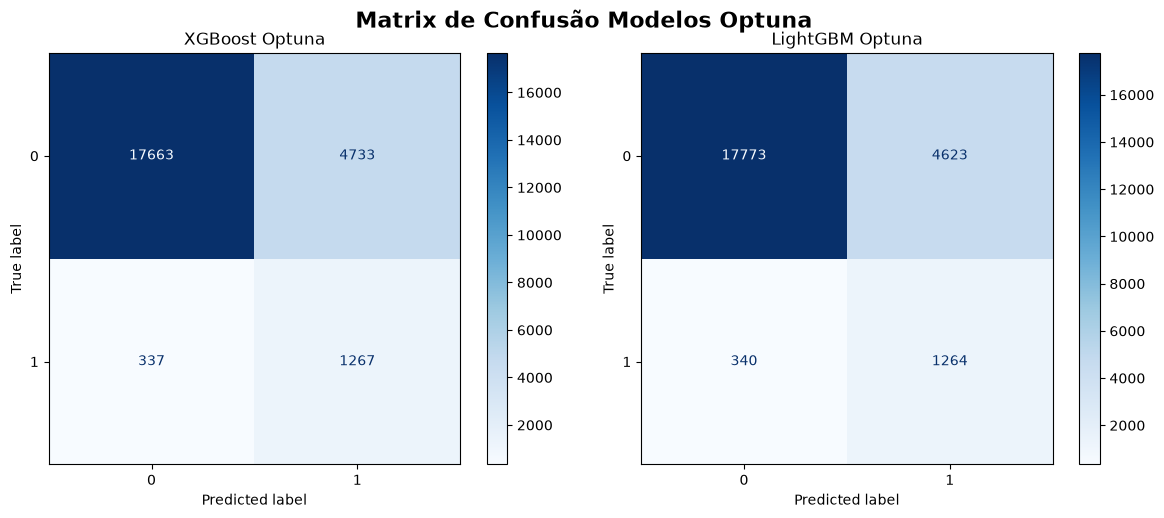

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(y_val, previsao_xgb_optuna, cmap="Blues", ax=axes[0])
axes[0].set_title("XGBoost Optuna")

ConfusionMatrixDisplay.from_predictions(y_val, previsao_gbm_optuna, cmap="Blues", ax=axes[1])
axes[1].set_title("LightGBM Optuna")

plt.suptitle("Matrix de Confusão Modelos Optuna", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

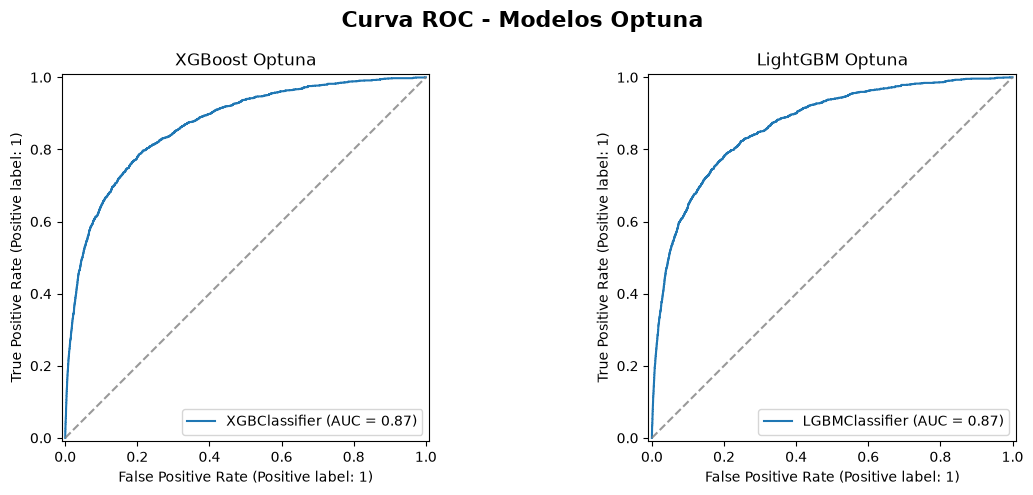

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

RocCurveDisplay.from_estimator(modelo_xgb_optuna, X_val, y_val, ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
axes[0].set_title("XGBoost Optuna")

RocCurveDisplay.from_estimator(modelo_gbm_optuna, X_val, y_val, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
axes[1].set_title("LightGBM Optuna")

plt.suptitle("Curva ROC - Modelos Optuna", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Comparação Final dos Modelos

In [41]:
modelos_finais = {
    "XGBoost Tunado": busca_xgb.best_estimator_,
    "Random Forest Tunado": busca_rf.best_estimator_,
    "LightGBM Tunado": busca_gbm.best_estimator_,
    "XGBoost Optuna": modelo_xgb_optuna,
    "LightGBM Optuna": modelo_gbm_optuna
}

resultados_tuning = []

for nome, modelo in modelos_finais.items():
    modelo.fit(X_treino, y_treino)
    previsao = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, previsao)

    metricas["Modelo"] = nome

    resultados_tuning.append(metricas)

resultados_tuning = pd.DataFrame(resultados_tuning)
resultados_tuning = resultados_tuning.sort_values(by="Recall_1", ascending=False)
resultados_tuning

,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1_Macro,Modelo
3,0.788750,0.981278,0.211167,0.788668,0.789900,0.603869,XGBoost Optuna
0,0.793833,0.981298,0.215356,0.794204,0.788653,0.608110,XGBoost Tunado
4,0.793208,0.981229,0.214710,0.793579,0.788030,0.607478,LightGBM Optuna
2,0.799083,0.980374,0.218115,0.800723,0.776185,0.611012,LightGBM Tunado
1,0.814333,0.979474,0.230537,0.818182,0.760599,0.622710,Random Forest Tunado


# 11. Análise do Threshold

In [42]:
proba_xgb = modelo_xgb_tunado.predict_proba(X_val)[:, 1]

In [43]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

resultados_threshold = []

for threshold in thresholds:
    
    pred_threshold = (proba_xgb >= threshold).astype(int)
    
    resultados_threshold.append({
        "Threshold": threshold,        
        "Acurácia": accuracy_score(y_val, pred_threshold),                
        "Recall_0": recall_score(y_val, pred_threshold, pos_label=0),        
        "Recall_1": recall_score(y_val, pred_threshold, pos_label=1),        
        "Precision_0": precision_score(y_val, pred_threshold, pos_label=0),        
        "Precision_1": precision_score(y_val, pred_threshold, pos_label=1),        
        "F1_0": f1_score(y_val, pred_threshold, pos_label=0),        
        "F1_1": f1_score(y_val, pred_threshold, pos_label=1),        
        "F1_Macro": f1_score(y_val, pred_threshold, average="macro")
    })

df_threshold = pd.DataFrame(resultados_threshold)

df_threshold.round(4)

,Threshold,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1_0,F1_1,F1_Macro
0,0.30,0.6417,0.6239,0.8897,0.9875,0.1449,0.7647,0.2492,0.5069
1,0.35,0.6827,0.6698,0.8628,0.9855,0.1576,0.7975,0.2666,0.5320
2,0.40,0.7183,0.7097,0.8385,0.9840,0.1714,0.8246,0.2846,0.5546
3,0.45,0.7565,0.7524,0.8136,0.9826,0.1905,0.8522,0.3087,0.5805
4,0.50,0.7938,0.7942,0.7887,0.9813,0.2154,0.8779,0.3383,0.6081
5,0.55,0.8260,0.8321,0.7413,0.9782,0.2403,0.8993,0.3629,0.6311
6,0.60,0.8544,0.8655,0.6995,0.9757,0.2713,0.9173,0.3910,0.6542


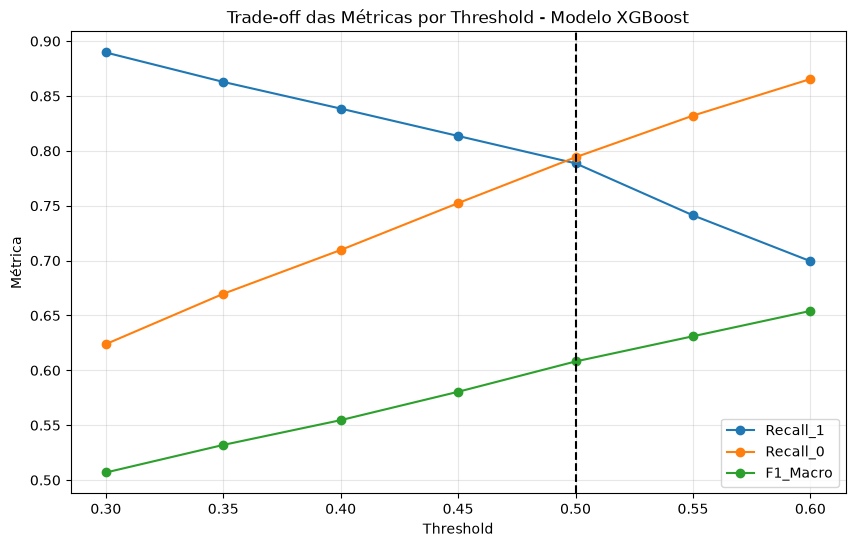

In [44]:
plt.figure(figsize=(10,6))

plt.plot(df_threshold["Threshold"], df_threshold["Recall_1"], marker="o", label="Recall_1")
plt.plot(df_threshold["Threshold"], df_threshold["Recall_0"], marker="o", label="Recall_0")
plt.plot(df_threshold["Threshold"], df_threshold["F1_Macro"], marker="o", label="F1_Macro")
plt.axvline(0.50, color="black", linestyle='--', linewidth=1.5)

plt.title("Trade-off das Métricas por Threshold - Modelo XGBoost")
plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# 12. Validação Cruzada do Modelo

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas = {
    "accuracy": "accuracy",
    "recall_0": make_scorer(recall_score, pos_label=0),
    "recall_1": make_scorer(recall_score, pos_label=1),
    "f1_0": make_scorer(f1_score, pos_label=0),
    "f1_1": make_scorer(f1_score, pos_label=1),
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc"
}

cv_resultados = cross_validate(
    estimator=modelo_xgb_tunado,
    X = X_treino,
    y= y_treino,
    cv=cv,
    scoring=metricas,
    n_jobs=-1
)

In [46]:
cv_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Recall_0", "Recall_1", "F1_0", "F1_1", "F1_Macro", "ROC_AUC"],
    
    "Média": [
        cv_resultados["test_accuracy"].mean(),
        cv_resultados["test_recall_0"].mean(),
        cv_resultados["test_recall_1"].mean(),
        cv_resultados["test_f1_0"].mean(),
        cv_resultados["test_f1_1"].mean(),
        cv_resultados["test_f1_macro"].mean(),
        cv_resultados["test_roc_auc"].mean()
    ],
    
    "Desvio padrão": [
        cv_resultados["test_accuracy"].std(),
        cv_resultados["test_recall_0"].std(),
        cv_resultados["test_recall_1"].std(),
        cv_resultados["test_f1_0"].std(),
        cv_resultados["test_f1_1"].std(),
        cv_resultados["test_f1_macro"].std(),
        cv_resultados["test_roc_auc"].std()
    ]
})

cv_df.round(4)

,Métrica,Média,Desvio padrão
0,Accuracy,0.7926,0.0042
1,Recall_0,0.7936,0.0042
2,Recall_1,0.7789,0.0101
3,F1_0,0.8772,0.0028
4,F1_1,0.3343,0.0064
5,F1_Macro,0.6057,0.0045
6,ROC_AUC,0.8637,0.0050


# 13. Avaliação Final do Conjunto de Teste

In [47]:
threshold_final = 0.40

proba_teste = modelo_xgb_tunado.predict_proba(X_teste)[:, -1]

proba_teste_final = (proba_teste >= threshold_final).astype(int)

In [48]:
print("Modelo Final - Threshold 0.40")
print(classification_report(y_teste, proba_teste_final))

Modelo Final - Threshold 0.40
              precision    recall  f1-score   support

           0       0.99      0.71      0.83     27995
           1       0.18      0.85      0.29      2005

    accuracy                           0.72     30000
   macro avg       0.58      0.78      0.56     30000
weighted avg       0.93      0.72      0.79     30000



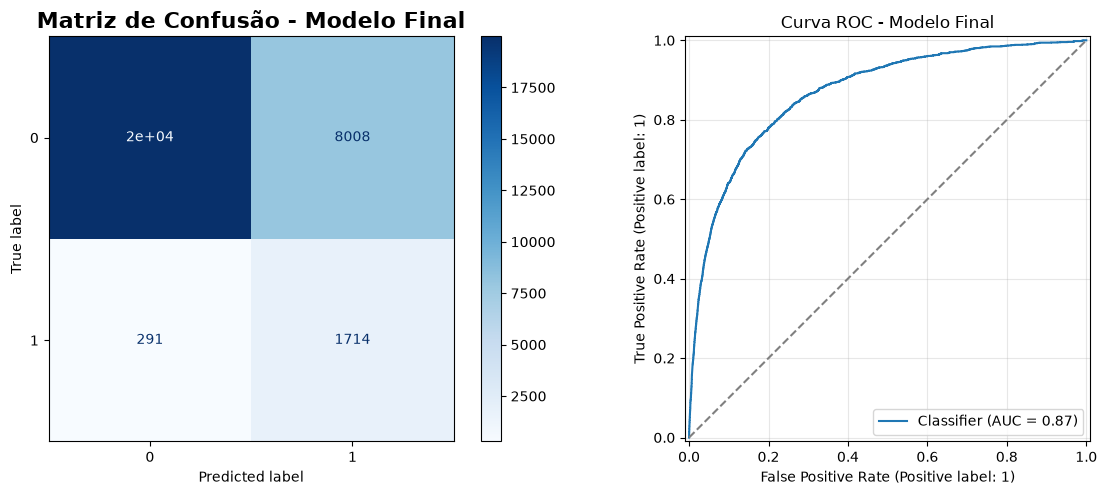

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Matriz de Confusão
ConfusionMatrixDisplay.from_predictions(y_teste, proba_teste_final, cmap="Blues", ax=ax[0])
ax[0].set_title("Matriz de Confusão - Modelo Final", fontsize=16, fontweight="bold")

# Curva ROC
RocCurveDisplay.from_predictions(y_teste, proba_teste, ax=ax[1])
ax[1].plot([0,1], [0,1], linestyle='--', color='gray')
ax[1].set_title("Curva ROC - Modelo Final")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 14. Verificando Overfitting do Modelo

In [50]:
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=modelo_xgb_tunado,
    X=X_treino,
    y=y_treino,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring=scorer_recall_1,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = validation_scores.mean(axis=1)

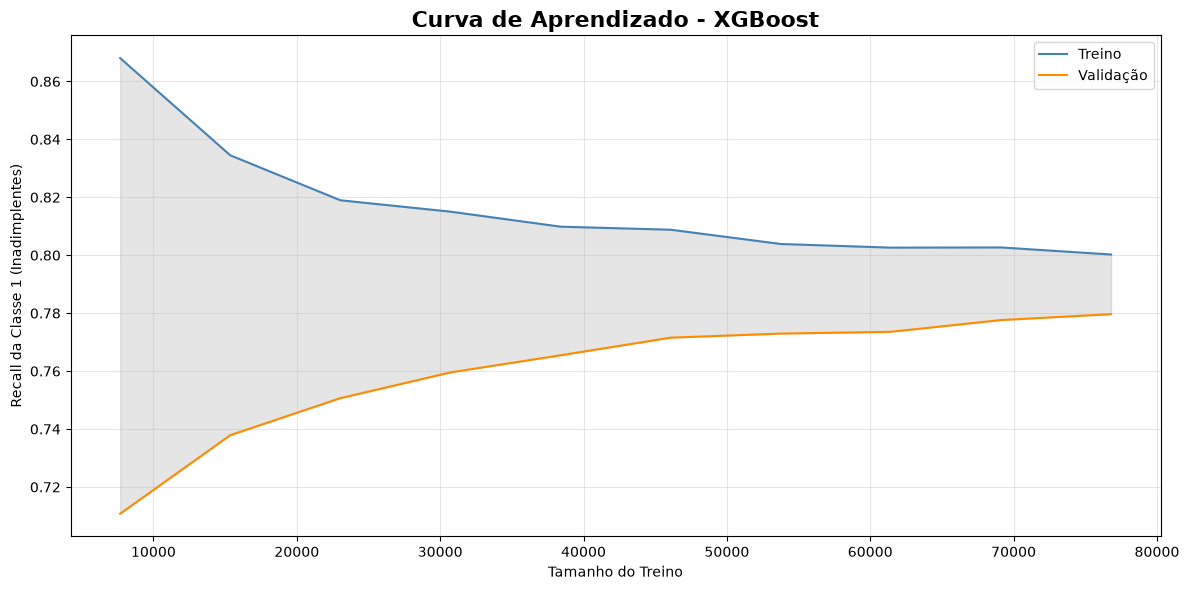

In [51]:
plt.figure(figsize=(12,6))

plt.plot(train_sizes, train_mean, label="Treino", color="steelblue")
plt.plot(train_sizes, val_mean, label="Validação", color="darkorange")
plt.fill_between(train_sizes, train_mean, val_mean, alpha=0.2, color="gray")
plt.title("Curva de Aprendizado - XGBoost", fontsize=16, fontweight="bold")
plt.xlabel("Tamanho do Treino")
plt.ylabel("Recall da Classe 1 (Inadimplentes)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
gap_final = train_mean[-1] - val_mean[-1]

print(f"Recall Classe 1 final - Treino :{train_mean[-1]:.4f}")
print(f"Recall Classe 1 final - Validação :{val_mean[-1]:.4f}")
print(f"Gap Final: {gap_final:.4f}")

Recall Classe 1 final - Treino :0.8002
Recall Classe 1 final - Validação :0.7796
Gap Final: 0.0206


# 15. Feature Importance - Modelo XGBoost

In [53]:
df_importance = pd.DataFrame({
    "feature": X_treino.columns,
    "importance": modelo_xgb_tunado.feature_importances_
})

df_importance = df_importance.sort_values(by="importance", ascending=False)
df_importance

,feature,importance
10,total_atrasos,0.627755
11,utilizacao_credito,0.119810
0,atraso_grave,0.084451
4,emprestimos_imobiliarios,0.034823
2,atrasos_60_89_dias,0.034088
5,idade,0.020247
1,atrasos_30_59_dias,0.017385
6,linhas_credito_abertas,0.016610
9,renda_mensal,0.014447
8,razao_divida,0.014168


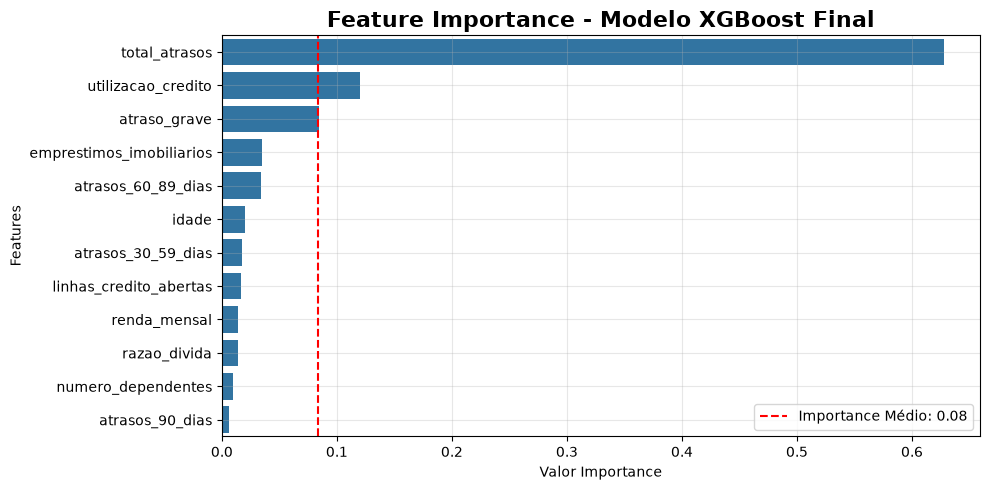

In [54]:
importance_medio = df_importance["importance"].mean()

plt.figure(figsize=(10,5))

sns.barplot(x=df_importance["importance"], y=df_importance["feature"])
plt.axvline(importance_medio, color="red", linestyle='--', label=f"Importance Médio: {importance_medio:.2f}")
plt.title("Feature Importance - Modelo XGBoost Final", fontsize=16, fontweight="bold")
plt.xlabel("Valor Importance")
plt.ylabel("Features")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 16. Interpretabilidade do Modelo com SHAP

In [59]:
explainer = shap.TreeExplainer(modelo_xgb_tunado)

shap_values = explainer(X_teste)

In [60]:
print(f"SHAPE X_teste: {X_teste.shape}")
print(f"SHAPE SHAP: {shap_values.shape}")

SHAPE X_teste: (30000, 12)
SHAPE SHAP: (30000, 12)


## Importância Global das Features

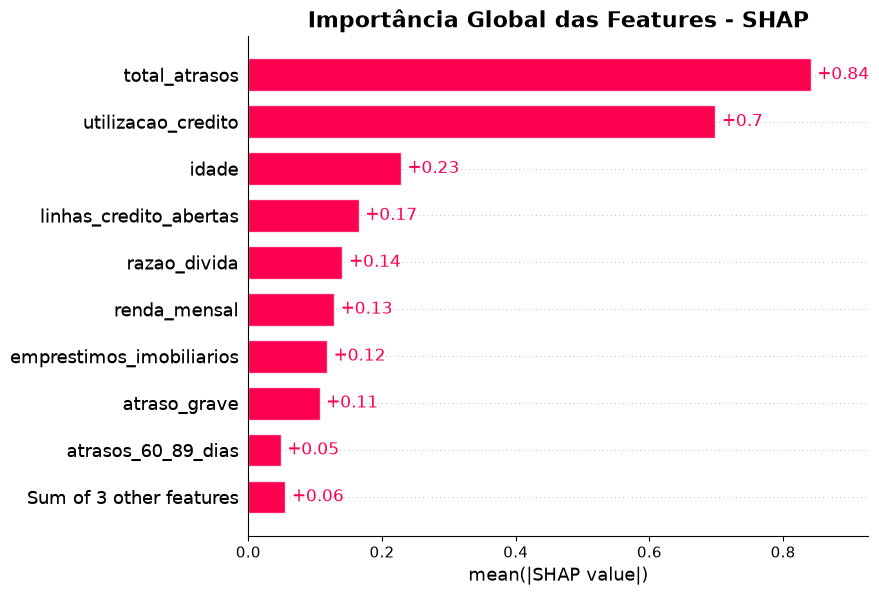

In [61]:
shap.plots.bar(
    shap_values,
    max_display=10,
    show=False
)
plt.title("Importância Global das Features - SHAP", fontsize=16, fontweight="bold")
plt.show()

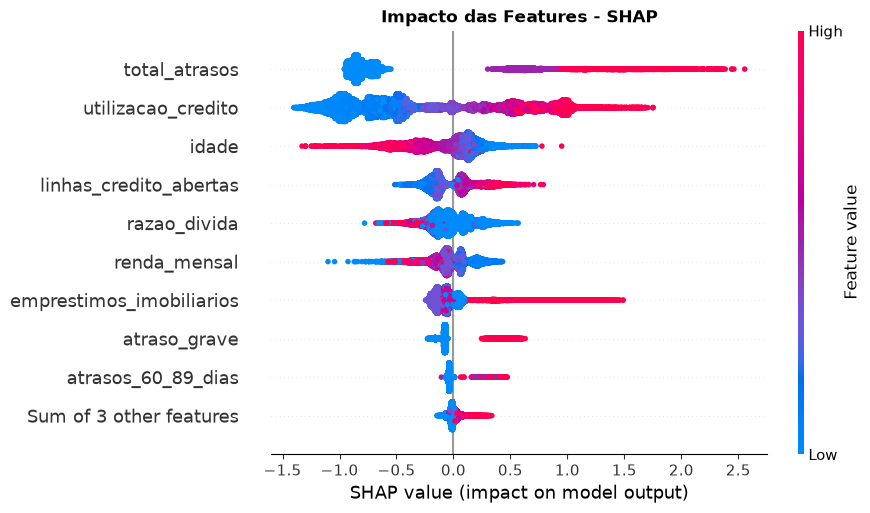

In [62]:
shap.plots.beeswarm(
    shap_values,
    max_display=10,
    show=False
)
plt.title("Impacto das Features - SHAP", fontweight="bold")
plt.show()

## Dependência do "Total Atrasos"

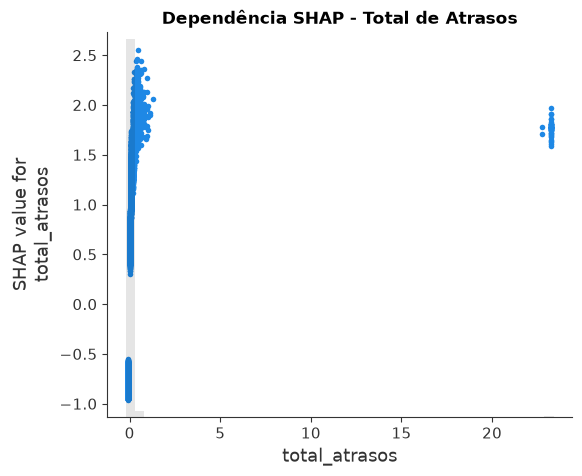

In [68]:
shap.plots.scatter(
    shap_values[:, "total_atrasos"],
    show=False
)

plt.title(
    "Dependência SHAP - Total de Atrasos",
    fontweight="bold"
)

plt.show()

## Explicação individual da Previsão

Valor Real        -> 0
Previsão do Modelo -> 0
Probabilidade      -> 17.09%
Threshold          -> 0.40


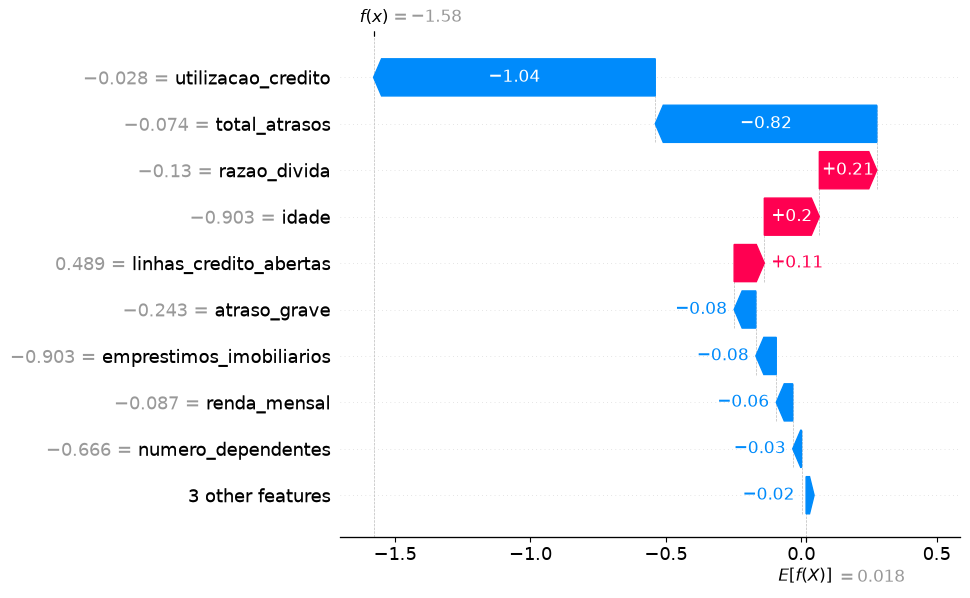

In [71]:
indice_cliente = 3
threshold = 0.40

# Cliente pela posição dentro do conjunto de teste
cliente_df = X_teste.iloc[[indice_cliente]]

# Valor real
previsao_real = y_teste.iloc[indice_cliente]

# Probabilidade de inadimplência
probabilidade = modelo_xgb_tunado.predict_proba(cliente_df)[0, 1]

# Previsão utilizando o threshold escolhido
previsao_modelo = int(probabilidade >= threshold)

print(f"Valor Real        -> {previsao_real}")
print(f"Previsão do Modelo -> {previsao_modelo}")
print(f"Probabilidade      -> {probabilidade:.2%}")
print(f"Threshold          -> {threshold:.2f}")

# Explicação individual
shap.plots.waterfall(
    shap_values[indice_cliente],
    max_display=10
)

# Salvando Pipeline do Modelo + Preprocessamento

In [72]:
pipeline_final = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo_final", modelo_xgb_tunado)
])

In [73]:
joblib.dump(pipeline_final, "../models/pipeline_modelo.pkl")

print("Pipeline Salvo com Sucesso!!")

Pipeline Salvo com Sucesso!!


# Impacto Financeiro Potencial

Além das métricas preditivas, foi realizada uma simulação para estimar o
potencial impacto financeiro do modelo na gestão de risco de crédito.

Como o dataset não possui valores financeiros reais, foram utilizadas
premissas hipotéticas para demonstrar como a identificação antecipada de
clientes de risco pode gerar valor para o negócio.

In [85]:
threshold = 0.40

probabilidades = modelo_xgb_tunado.predict_proba(X_teste)[:, 1]

pred_final = (probabilidades >= threshold).astype(int)

In [87]:
total_clientes = len(y_teste)

inadimplentes_reais = (y_teste == 1).sum()

clientes_sinalizados = pred_final.sum()

inadimplentes_detectados = ((y_teste == 1) & (pred_final == 1)).sum()

porcentagem_detectado = (inadimplentes_detectados / inadimplentes_reais) * 100

print(f"Clientes Avaliado: {total_clientes}")
print(f"Clientes Sinalizados: {clientes_sinalizados}")
print(f"Inadimplentes Reais: {inadimplentes_reais}")
print(f"Inadimplentes Identificados: {inadimplentes_detectados}")
print(f"Porcentagem de Inadimplentes Detectados: {porcentagem_detectado:.1f}%")

Clientes Avaliado: 30000
Clientes Sinalizados: 9722
Inadimplentes Reais: 2005
Inadimplentes Identificados: 1714
Porcentagem de Inadimplentes Detectados: 85.5%


### Resultado Operacional

O modelo identificou **1.714 dos 2.005 clientes inadimplentes**, alcançando
**85,5% de detecção**.

A partir desse resultado, será simulada uma estratégia de atuação preventiva
sobre os clientes sinalizados pelo modelo.

In [88]:
# Valores hipotéticos para simulação

perda_media_inadimplente = 5000   # R$ por cliente inadimplente
taxa_recuperacao = 0.30           # 30% da perda pode ser evitada
custo_acao = 40                   # custo por cliente abordado

### Premissas da Simulação

Para estimar o impacto financeiro foram considerados valores hipotéticos:

- **R$ 5.000** de perda média por cliente inadimplente;
- **30% de efetividade** das ações preventivas;
- **R$ 40** de custo por cliente sinalizado.

Os valores são utilizados exclusivamente para demonstrar o potencial econômico da solução.

In [89]:
# Valor financeiro associado aos inadimplentes encontrados
perda_identificada = (inadimplentes_detectados * perda_media_inadimplente)

# Parte da perda que poderia ser evitada
valor_recuperado = (perda_identificada * taxa_recuperacao)

# Custo das ações preventivas
custo_total = (clientes_sinalizados * custo_acao)

# Benefício líquido estimado
beneficio_modelo = (valor_recuperado - custo_total)

print(f"Perda identificada: R$ {perda_identificada:,.2f}")
print(f"Valor potencialmente recuperado: R$ {valor_recuperado:,.2f}")
print(f"Custo das ações: R$ {custo_total:,.2f}")
print(f"Benefício líquido estimado: R$ {beneficio_modelo:,.2f}")

Perda identificada: R$ 8,570,000.00
Valor potencialmente recuperado: R$ 2,571,000.00
Custo das ações: R$ 388,880.00
Benefício líquido estimado: R$ 2,182,120.00


### Comparação com uma Estratégia Aleatória

Para avaliar o valor gerado pela capacidade preditiva do modelo, foi criado
um cenário de referência no qual a **mesma quantidade de clientes é abordada**,
porém sem utilizar informações de risco.

A diferença entre os resultados representa o ganho obtido pela priorização
realizada pelo modelo.

In [90]:
percentual_priorizado = (clientes_sinalizados / total_clientes)

# Quantidade esperada de inadimplentes encontrados aleatoriamente
inadimplentes_aleatorio = (inadimplentes_reais *  percentual_priorizado)

valor_recuperado_aleatorio = (inadimplentes_aleatorio * perda_media_inadimplente * taxa_recuperacao)

beneficio_aleatorio = (valor_recuperado_aleatorio - custo_total)

valor_incremental = (beneficio_modelo - beneficio_aleatorio)

print(f"Benefício com Modelo: R$ {beneficio_modelo:,.2f}")
print(f"Benefício Seleção Aleatória: R$ {beneficio_aleatorio:,.2f}")
print(f"Valor Incremental do Modelo: R$ {valor_incremental:,.2f}")

Benefício com Modelo: R$ 2,182,120.00
Benefício Seleção Aleatória: R$ 585,750.50
Valor Incremental do Modelo: R$ 1,596,369.50


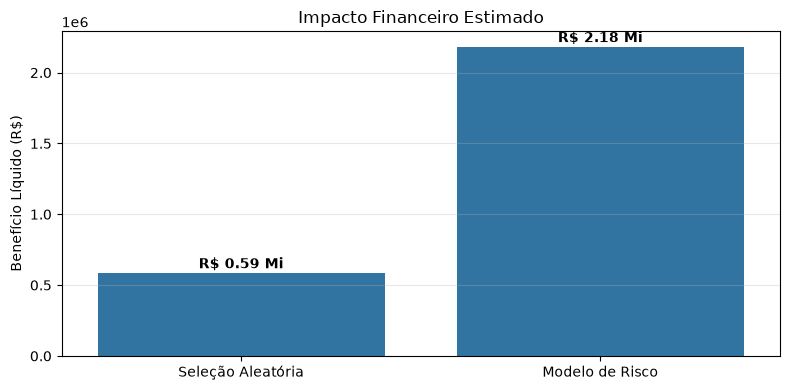

In [94]:
impacto = pd.DataFrame({
    "Estratégia": [
        "Seleção Aleatória",
        "Modelo de Risco"
    ],
    "Benefício Líquido": [
        beneficio_aleatorio,
        beneficio_modelo
    ]
})

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=impacto,
    x="Estratégia",
    y="Benefício Líquido"
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"R$ {v/1_000_000:.2f} Mi"
            for v in container.datavalues
        ],
        padding=1,
        fontweight="bold"
    )

plt.title("Impacto Financeiro Estimado")
plt.xlabel("")
plt.ylabel("Benefício Líquido (R$)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusão

Com as premissas adotadas, o modelo apresentou um **benefício líquido potencial
de aproximadamente R$ 2,18 milhões**.

Uma estratégia aleatória com o mesmo volume de ações apresentaria benefício
estimado de aproximadamente **R$ 586 mil**, resultando em um **ganho incremental
de aproximadamente R$ 1,60 milhão** pela utilização do modelo.

Embora os valores financeiros sejam hipotéticos, a simulação demonstra como
a capacidade de identificar clientes de maior risco pode ser transformada em
**redução potencial de perdas e geração de valor para o negócio**.